# Exercise 4: Transformers on Images + GLU-MLP Ablations (ViT × GLU Variants)

## In this exercise you will combine two influential ideas:

Vision Transformers (ViT) from “An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale” (Dosovitskiy et al., 2020) https://arxiv.org/pdf/2010.11929
ViT shows that you can treat an image like a sequence of tokens by splitting it into non-overlapping patches (e.g. 16×16 in the paper), embedding each patch into a vector, adding positional information, and then applying standard Transformer blocks for classification.

Gated MLPs (GLU variants) from “GLU Variants Improve Transformer” (Shazeer, 2020) https://arxiv.org/pdf/2002.05202
Shazeer proposes replacing the standard Transformer feed-forward layer (FFN/MLP) with gated linear unit (GLU) variants such as GEGLU and SwiGLU, which often improves training dynamics and final performance under comparable compute/parameter budgets.

## What you will do

You will implement a tiny ViT-style classifier for MNIST, then run a controlled ablation where you replace the MLP inside each Transformer block:

Baseline FFN (GELU):
Linear(d_model → d_ff) → GELU → Linear(d_ff → d_model)

GLU-family MLPs (choose at least two and justify):

GEGLU, SwiGLU, other activation functions

Your goal is to evaluate whether these GLU variants change:

- convergence speed (loss vs steps),

- final test accuracy,

- and/or stability across runs.

## Key ViT concepts you will implement

- To convert MNIST images into Transformer tokens, you will:
  Patchify each 28×28 image into non-overlapping P×P patches.
  If P=4, then you get a 7×7 patch grid → 49 tokens per image.

- Embed patches with a linear layer: patch vectors → d_model.

- Add positional embeddings so the model knows where each patch came from.

- Apply n_layers Transformer encoder blocks.

- Pool token features (e.g., mean pooling) and project to 10 classes.

## Key GLU concept you will implement

GLU-style MLPs replace a standard FFN with a gating mechanism:
compute two projections a and b, apply a nonlinearity to a (variant-dependent), multiply elementwise: act(a) * b, project back to d_model.
To keep the comparison fair, use the 2/3 width rule from Shazeer.

What we provide vs what you implement

### We provide:

- MNIST loading + dataloaders

- a minimal training loop structure (AdamW)

- a suggested small model configuration that runs on CPU

### You implement:

- patch tokenization (patchify)

- patch embedding + positional embedding strategy

- a pre-LN Transformer encoder block using nn.MultiheadAttention

- at least two GLU MLP variants + one FFN baseline

- metric logging sufficient to support your conclusion

## Deliverables

Run at least 3 variants (baseline + the activation functions you choose for GLU) and report:

- final and best test accuracy

- number of trainable parameters

- a plot or printed summary of loss/accuracy over epochs

- a short discussion of your results

In [1]:
from __future__ import annotations

import math
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
def patchify(x: torch.Tensor, patch_size: int) -> torch.Tensor:
    # convert images to patch tokens: 
    # (B, 28, 28) -> 
    # (B, 28/patch_size, patch_size, 28/patch_size patch_size) ->
    # (B, (28/patch_size)**2, (patch_size)**2)

    # get image shape (sould be (B, 28, 28)) 
    x = x.squeeze(1)
    B, img_dim_1, img_dim_2 = x.shape # img dim 1 and img dim 2 should be the same

    # define (28/patch_size) as new dim
    new_dim = int(img_dim_1/patch_size)

    # change the view -> split B*28 * 28 into B*7*4*7*4
    x = x.view((B, new_dim, patch_size, new_dim, patch_size))
    # permute the dimensions, so that B*7*4*7*4 -> B*7*7*4*4
    x = x.permute(0, 1, 3, 2, 4)
    # reshape such that B*7*7*4*4 -> B*49*16
    x = x.reshape(B, new_dim*new_dim, patch_size*patch_size)

    return x



In [3]:
# TODO: Add positional encoding as done in the ViT paper and patch projection
class PatchEmbed(nn.Module):
    def __init__(self, patch_dim: int, d_model: int):
        super().__init__()
        # define linear layer
        self.linear = nn.Linear(patch_dim, d_model)

    def forward(self, x_patches: torch.Tensor) -> torch.Tensor:
        # apply linear layer -> turn raw pixels into (hopefully) richer embeddings
        x_embedded = self.linear(x_patches)
        return x_embedded


class PositionalEmbedding(nn.Module):
    def __init__(self, num_tokens: int, d_model: int):
        super().__init__()
        # make learnable tensor to include in parameters()
        self.positional_encoding = nn.Parameter(torch.randn(num_tokens, d_model))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # add positional encodings to embedded tensor (-> to know postion aswell)
        x += self.positional_encoding
        return x

In [4]:
# TODO: Define the variants you want to compare against each other from the GLU paper. Justify your choice.
class FeedForward(nn.Module):
    """
    Standard Transformer FFN:
      x -> Linear(d_model->d_ff) -> GELU -> Dropout -> Linear(d_ff->d_model) -> Dropout
    """
    def __init__(self, d_model: int, d_ff: int, dropout: float):
        super().__init__()
        # define Standard Transformer FFN as described above
        self.linear_1 = nn.Linear(d_model, d_ff)
        self.gelu = nn.GELU()
        self.dropout_1 = nn.Dropout(dropout)
        self.linear_2 = nn.Linear(d_ff, d_model)
        self.dropout_2 = nn.Dropout(dropout)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # define residual
        residual = x 
        # apply Standard Transformer FFN (STFFN)
        x = self.linear_1(x)
        x = self.gelu(x)
        x = self.dropout_1(x)
        x = self.linear_2(x)
        x = self.dropout_2(x)
        return x + residual # return resulting tensor from STFFN + residuals


class GLUFeedForward(nn.Module):
    """GLU-family FFN"""
    def __init__(self, d_model: int, d_ff_gated: int, dropout: float, variant: str):
        super().__init__()
        self.variant = variant
        self.W_gate = nn.Linear(d_model, d_ff_gated)
        self.W_value = nn.Linear(d_model, d_ff_gated)
        self.linear_2 = nn.Linear(d_ff_gated, d_model)
        self.dropout_1 = nn.Dropout(dropout)
        self.dropout_2 = nn.Dropout(dropout)

        # select which GLU variant should be used
        if self.variant == "glu":
            self.act_gate = nn.Sigmoid()
        elif self.variant == "geglu":
            self.act_gate = nn.GELU()
        elif self.variant == "swiglu":
            self.act_gate = nn.SiLU()
        else:
            raise ValueError(f"Unsupported variant: {self.variant}")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x

        # seperate into gate and value
        gate_raw = self.W_gate(x)
        value = self.W_value(x)
        
        # apply chosen gate to gate part
        gate = self.act_gate(gate_raw)
        
        # perform elementwise multiplication of gate and value in a dropout layer
        x = self.dropout_1(gate*value)
        x = self.linear_2(x)
        x = self.dropout_2(x)

        return x + residual # return resulting tensor from GLU-family FFN + residuals


In [5]:
class TransformerEncoderBlock(nn.Module):
    """
    Pre-LN encoder block:
      x = x + Dropout(SelfAttn(LN(x)))
      x = x + Dropout(MLP(LN(x)))
    """
    def __init__(self, d_model: int, n_heads: int, mlp: nn.Module, dropout: float):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model, 
            num_heads=n_heads, 
            dropout=dropout, 
            batch_first=True 
        )
        # LayerNorms -> normalize each patch's vector to mean=0 std=1
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        # MLP -> the FFN
        self.mlp = mlp
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        # Attention block
        x_norm = self.norm1(x)  # LayerNorm first
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)  # Self-attention
        x = x + self.dropout(attn_out)  # Residual
        
        # MLP block  
        x_norm = self.norm2(x)
        mlp_out = self.mlp(x_norm)
        x = x + self.dropout(mlp_out)  # Residual
        
        return x

In [6]:
class TinyViT(nn.Module):
    """
    Tiny ViT-style classifier for MNIST.
    - patchify -> patch embed -> pos embed -> blocks -> mean pool -> head
    """
    def __init__(
        self,
        patch_size: int,
        d_model: int,
        n_heads: int,
        n_layers: int,
        d_ff: int,
        dropout: float,
        mlp_kind: str,
    ):
        super().__init__()
        assert 28 % patch_size == 0
        grid = 28 // patch_size
        self.num_tokens = grid * grid
        self.patch_size = patch_size
        patch_dim = patch_size * patch_size

        # embedding the patches/positional embeddings
        self.patch_embed = PatchEmbed(patch_dim=patch_dim, d_model=d_model)
        self.pos_embed = PositionalEmbedding(num_tokens=self.num_tokens, d_model=d_model)


        # TODO: implement a strategy to select the right mlp version for your experiment
        def create_mlp():
            if mlp_kind == "standard":
                return FeedForward(d_model, d_ff, dropout)
            elif mlp_kind in ["glu", "geglu", "swiglu"]: 
                d_ff_gated = int(2 * d_ff / 3)  # Parameter trick
                return GLUFeedForward(d_model, d_ff_gated, dropout, mlp_kind)
            else:
                raise ValueError(f"Unknown mlp_kind: {mlp_kind}")



        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                d_model=d_model,
                n_heads=n_heads,
                mlp=create_mlp(),
                dropout=dropout,
            )
            for _ in range(n_layers)
        ])

        # TODO: Add a head to project to the amount of output classes you have
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # B = x.shape[0] 
        
        # Patchify: (B, 28, 28) -> (B, N, patch_dim)
        x = patchify(x, self.patch_size)  # Your patchify function
        # Embed: (B, N, patch_dim) -> (B, N, d_model)
        x = self.patch_embed(x)
        # Positional: (B, N, d_model) += pos_embed
        x = self.pos_embed(x)
        # Transformer blocks
        for block in self.blocks:
            x = block(x)
        # Mean pool over patches (ViT style)
        x = self.norm(x.mean(dim=1))  # (B, N, D) -> (B, D)
        # Classify
        logits = self.head(x)  # (B, D) -> (B, num_classes)
        return logits

In [7]:
@dataclass(frozen=True)
class TrainConfig:
    seed: int = 0
    batch_size: int = 128
    epochs: int = 3
    lr: float = 3e-4
    weight_decay: float = 0.01
    device: str = "cpu"  # set "cuda" if available

In [8]:
def train_one_run(
    mlp_kind: str,
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    cfg: TrainConfig,
) -> dict:
    model.to(cfg.device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    criterion = nn.CrossEntropyLoss()

    train_losses: list[float] = []
    test_accs: list[float] = []

    for epoch in range(cfg.epochs):

        # Train loop
        model.train()
        for i, (xb, yb) in enumerate(train_loader):
            xb = xb.to(cfg.device)
            yb = yb.to(cfg.device)

            logits = model(xb)
            loss = criterion(logits, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            train_losses.append(loss.item())

        # Evaluation loop NOTE: Should be no need to change this
        model.eval()
        correct = 0.0
        total = 0.0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(cfg.device)
                yb = yb.to(cfg.device)
                logits = model(xb)
                correct += (logits.argmax(dim=-1) == yb).float().sum().item()
                total += yb.numel()

        test_accs.append(correct / total)
        print(f"[{mlp_kind}] epoch {epoch+1}/{cfg.epochs} | test acc: {test_accs[-1]:.4f}")

    return {
        "mlp_kind": mlp_kind, "train_losses": train_losses, "test_accs": test_accs
    }

In [10]:
cfg = TrainConfig(seed=0, batch_size=128, epochs=5, lr=3e-4, weight_decay=0.01, device="cpu")

tfm = transforms.Compose([transforms.ToTensor()])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=tfm)
test_ds = datasets.MNIST(root="./data", train=False, download=True, transform=tfm)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)

# Tiny model example. TODO: You're welcome to experiment with these parameters
patch_size = 4
d_model = 64
n_heads = 4
n_layers = 2
d_ff = 256
dropout = 0.1

runs = ["standard", "standard","standard", "geglu","geglu","geglu", "swiglu","swiglu","swiglu"] 
results = []

for kind in runs:
    model = TinyViT(
        patch_size=patch_size,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        dropout=dropout,
        mlp_kind=kind,
    )
    # TODO: print anything you might want here
    print(f"\nRun: {kind} | " )
    out = train_one_run(kind, model, train_loader, test_loader, cfg)
    results.append(out)


Run: standard | 
[standard] epoch 1/5 | test acc: 0.8635
[standard] epoch 2/5 | test acc: 0.9070
[standard] epoch 3/5 | test acc: 0.9129
[standard] epoch 4/5 | test acc: 0.9382
[standard] epoch 5/5 | test acc: 0.9441

Run: standard | 
[standard] epoch 1/5 | test acc: 0.8552
[standard] epoch 2/5 | test acc: 0.8971
[standard] epoch 3/5 | test acc: 0.9191
[standard] epoch 4/5 | test acc: 0.9383
[standard] epoch 5/5 | test acc: 0.9442

Run: standard | 
[standard] epoch 1/5 | test acc: 0.8273
[standard] epoch 2/5 | test acc: 0.9045
[standard] epoch 3/5 | test acc: 0.9230
[standard] epoch 4/5 | test acc: 0.9317
[standard] epoch 5/5 | test acc: 0.9434

Run: geglu | 
[geglu] epoch 1/5 | test acc: 0.8757
[geglu] epoch 2/5 | test acc: 0.9183
[geglu] epoch 3/5 | test acc: 0.9358
[geglu] epoch 4/5 | test acc: 0.9469
[geglu] epoch 5/5 | test acc: 0.9553

Run: geglu | 
[geglu] epoch 1/5 | test acc: 0.8780
[geglu] epoch 2/5 | test acc: 0.9168
[geglu] epoch 3/5 | test acc: 0.9366
[geglu] epoch 4/5 | 

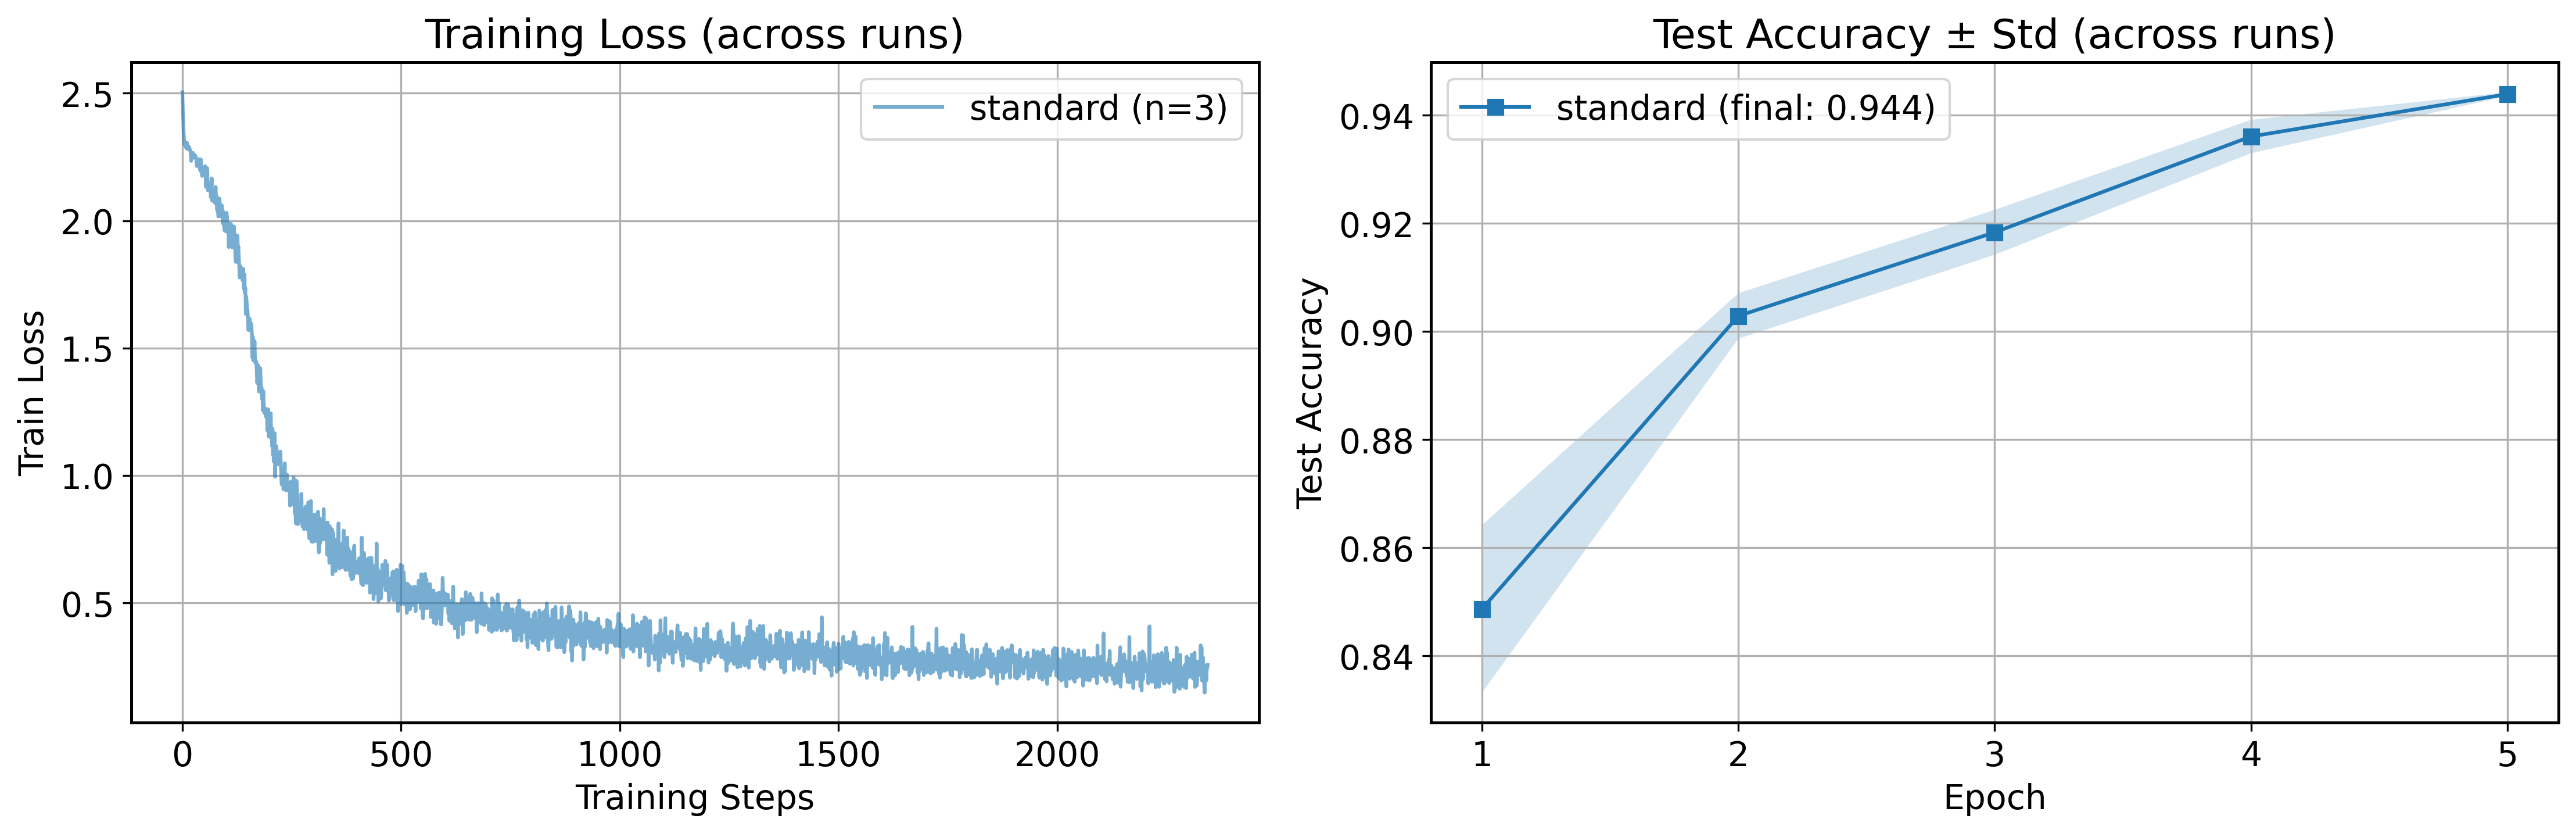


GLU Variants Comparison:
   MLP Kind Final Test Acc Best Test Acc  N Runs
0  standard  0.944 ± 0.000         0.944       3


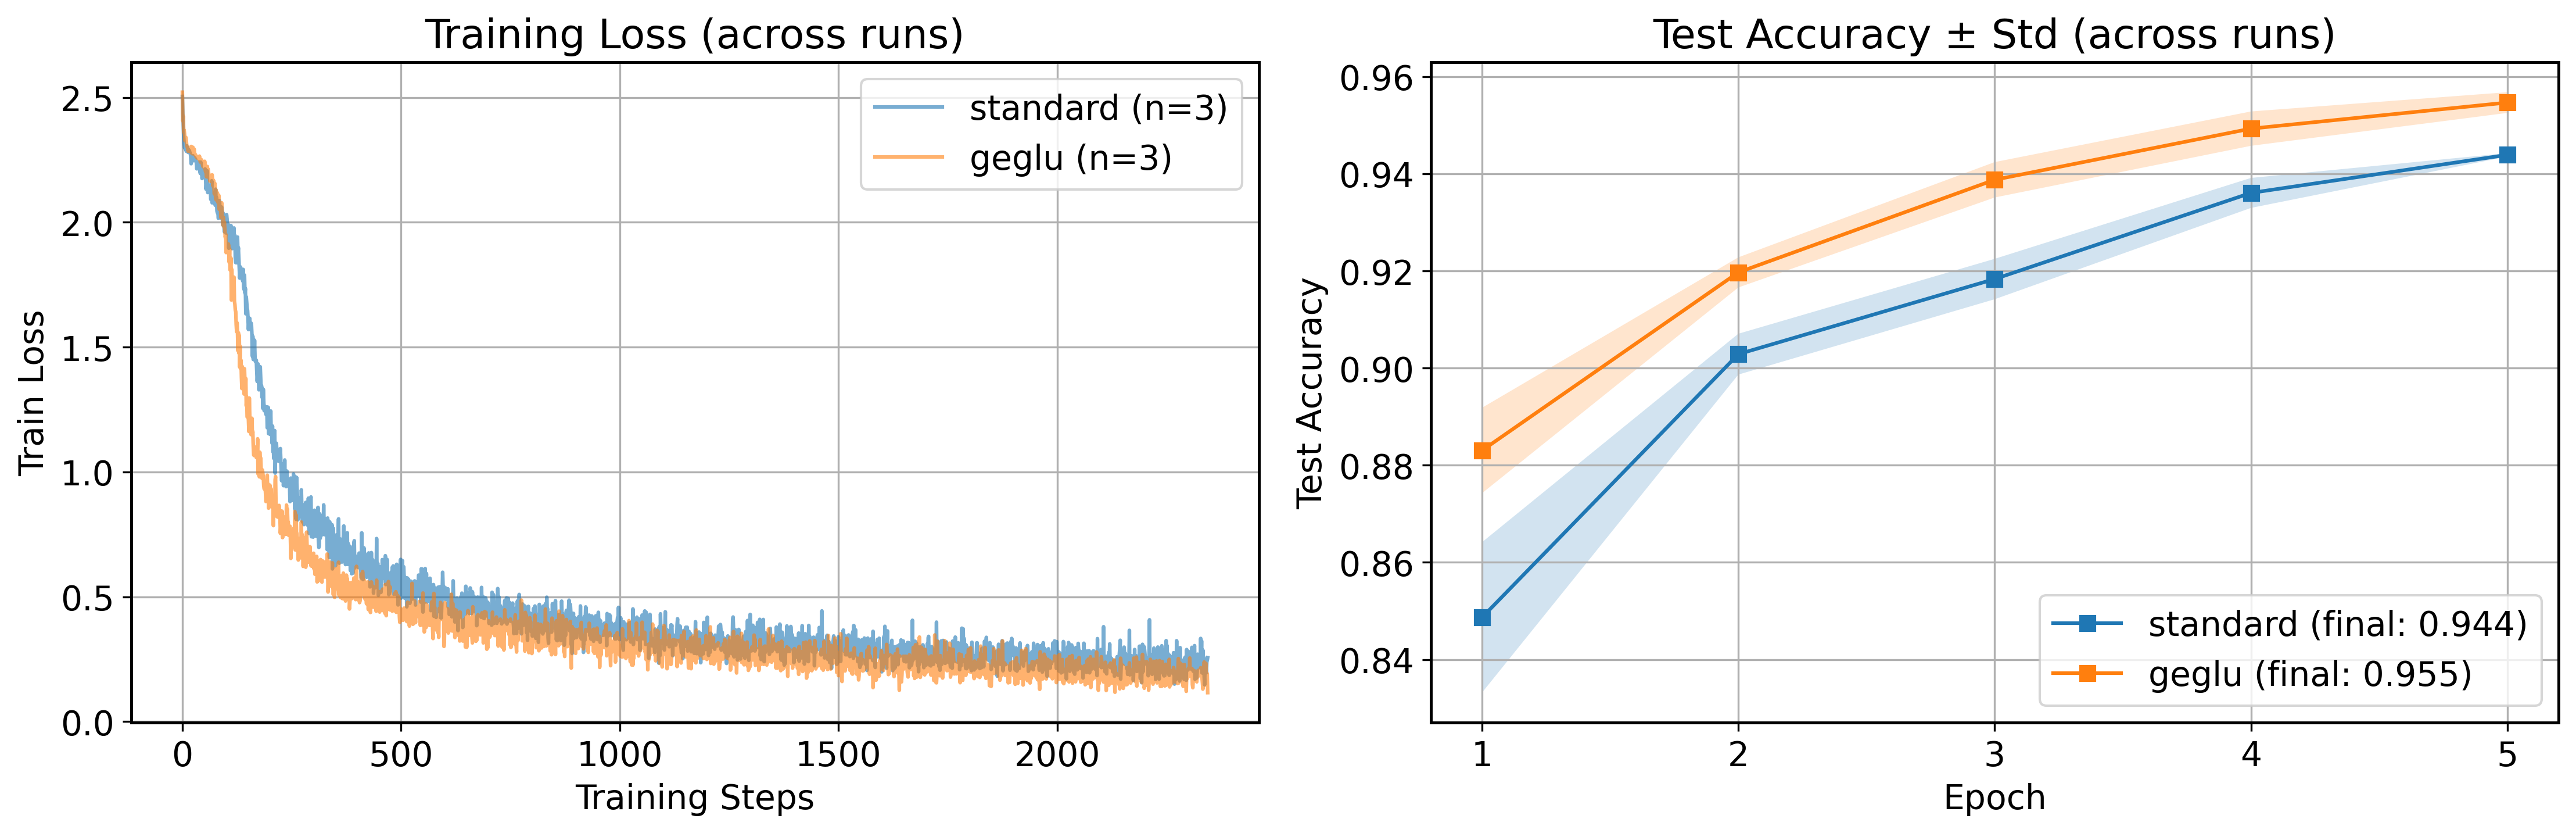


GLU Variants Comparison:
   MLP Kind Final Test Acc Best Test Acc  N Runs
0  standard  0.944 ± 0.000         0.944       3
1     geglu  0.955 ± 0.002         0.955       3


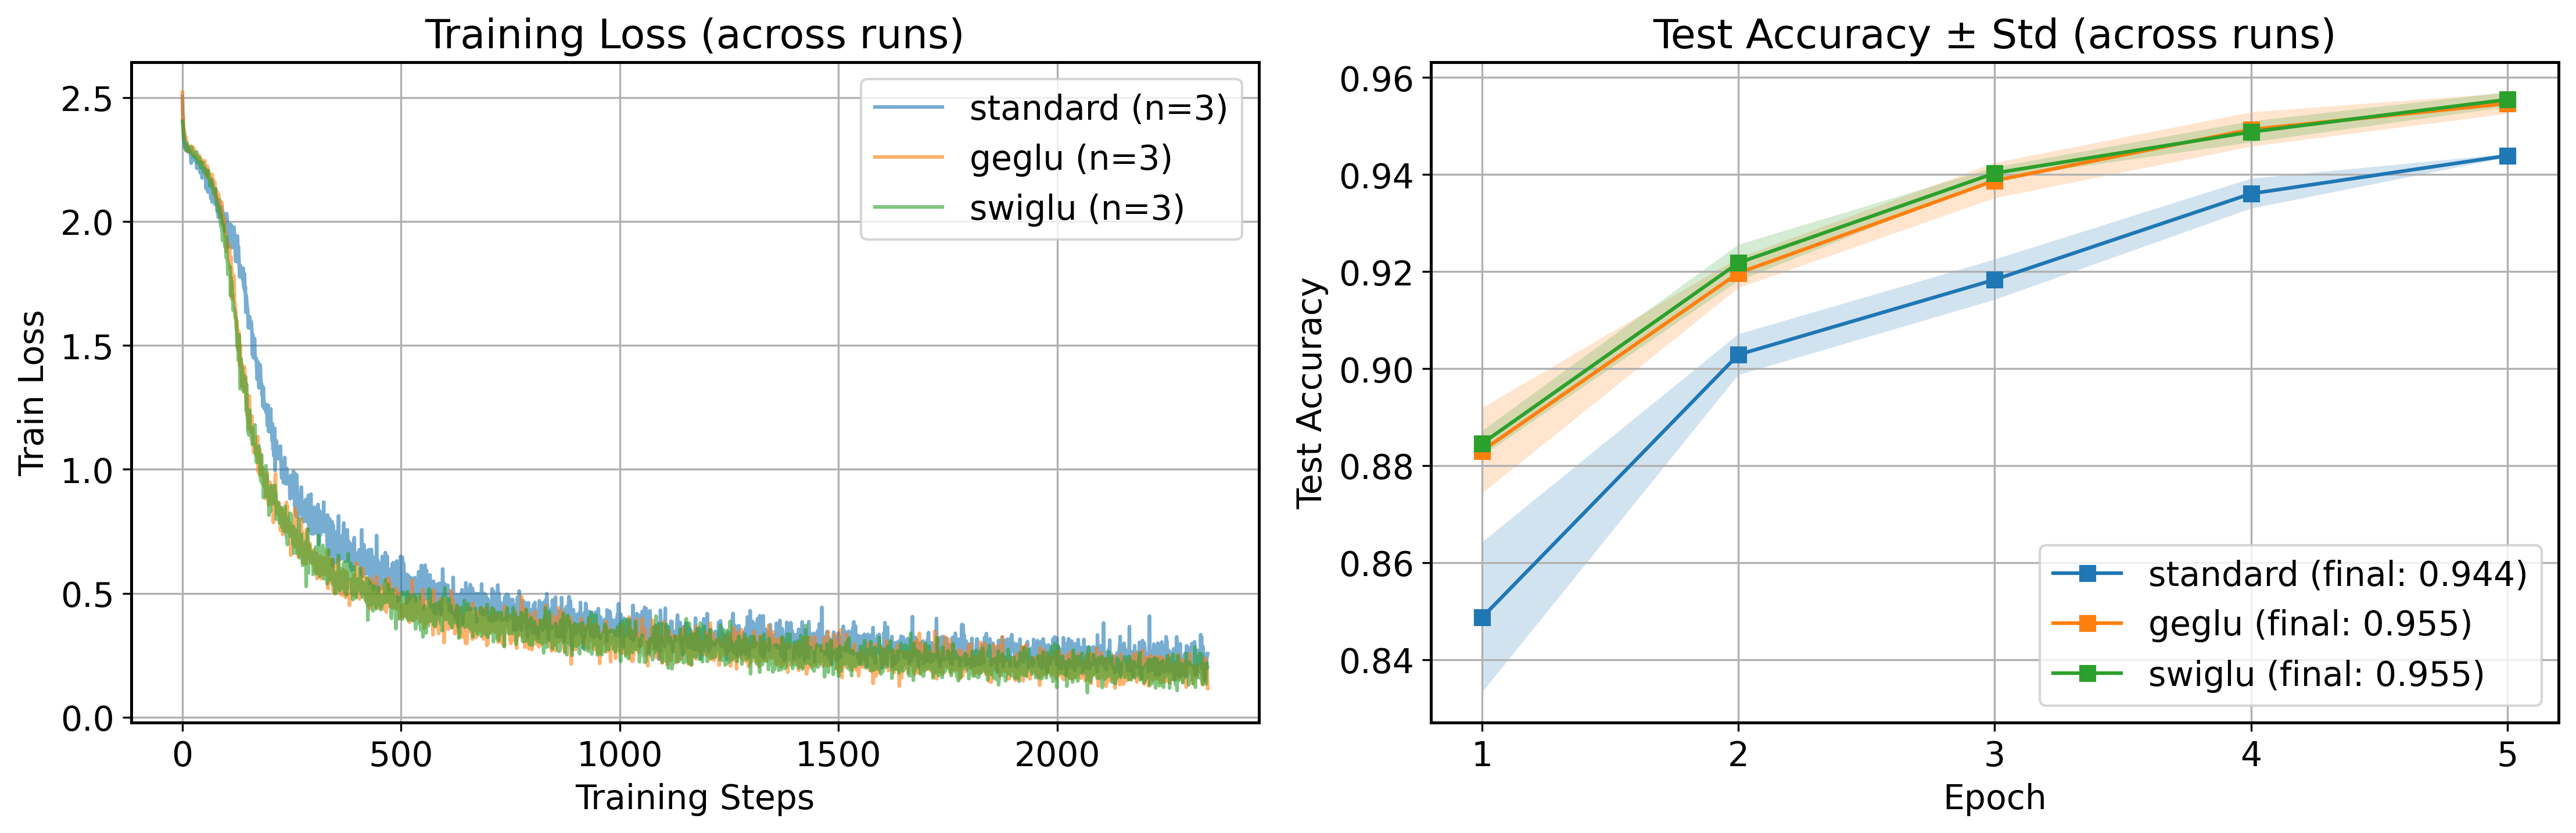


GLU Variants Comparison:
   MLP Kind Final Test Acc Best Test Acc  N Runs
0  standard  0.944 ± 0.000         0.944       3
1     geglu  0.955 ± 0.002         0.955       3
2    swiglu  0.955 ± 0.002         0.955       3


In [ ]:
Plot_Active = False

if (Plot_Active):
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd


    plt.rcParams.update({
    "font.size": 14,
    "figure.dpi": 300,
    "axes.linewidth": 1.2,
    })
    

    # Group by mlp_kind
    variants = {}
    for r in results:
        kind = r['mlp_kind']
        if kind not in variants:
            variants[kind] = {'train_losses': [], 'test_accs': []}
        variants[kind]['train_losses'].append(r['train_losses'])
        variants[kind]['test_accs'].append(r['test_accs'])


    # Average across runs
    epochs = len(next(iter(results))['train_losses'])  # Assume all same length
    avg_results = {}

    for kind, data in variants.items():
        n_runs = len(data['train_losses'])
    
        # Average each epoch across runs
        avg_train_loss = np.mean(data['train_losses'], axis=0)  # Shape: (epochs,)
        avg_test_acc = np.mean(data['test_accs'], axis=0)
        
        # Std for error bars
        std_train_loss = np.std(data['train_losses'], axis=0)
        std_test_acc = np.std(data['test_accs'], axis=0)
        
        avg_results[kind] = {
            'train_loss': avg_train_loss,
            'train_loss_std': std_train_loss,
            'test_acc': avg_test_acc,
            'test_acc_std': std_test_acc,
            'n_runs': n_runs,
            'final_acc': avg_test_acc[-1],
            'best_acc': np.max(avg_test_acc)
        }

        plt.figure(figsize=(15, 5))

        plt.subplot(1, 2, 1)
        for kind, data in avg_results.items():
            epochs_range = range(epochs)
            plt.plot(epochs_range, data['train_loss'], '-',linewidth=1.5,alpha=0.6, label=f"{kind} (n={data['n_runs']})")
        plt.xlabel('Training Steps')
        plt.ylabel('Train Loss')
        # plt.title('Training Loss ± Std (across runs)')
        plt.title('Training Loss (across runs)')

        plt.legend()
        plt.grid(True)

        plt.subplot(1, 2, 2)
        for kind, data in avg_results.items():
            plt.plot(range(1,6), data['test_acc'], 's-', label=f"{kind} (final: {data['final_acc']:.3f})")
            plt.fill_between(range(1,6), 
                            data['test_acc'] - data['test_acc_std'],
                            data['test_acc'] + data['test_acc_std'], alpha=0.2)
        plt.xlabel('Epoch')
        plt.xticks( [1, 2, 3, 4, 5])
        plt.ylabel('Test Accuracy')
        plt.title('Test Accuracy ± Std (across runs)')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.savefig("ex4_mnist"+kind+".svg", format="svg")

        plt.show()


        summary_df = pd.DataFrame({
            'MLP Kind': list(avg_results.keys()),
            'Final Test Acc': [f"{data['final_acc']:.3f} ± {data['test_acc_std'][-1]:.3f}" for _, data in avg_results.items()],
            'Best Test Acc': [f"{data['best_acc']:.3f}" for _, data in avg_results.items()],
            'N Runs': [data['n_runs'] for _, data in avg_results.items()]
        })
        print("\nGLU Variants Comparison:")
        print(summary_df.round(4))